# Create TPM data
June 17, 2025

**Goals:**
Load the genic and nongenic dataset and RNA seq data. Create TPM data set from the combined transcripts datasets for each replicate and sample.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
from src.transcripts_dataset import load_transcripts_sets

output_dir = 'output/draft4_run/'

combined_gene_nongenic = load_transcripts_sets(output_dir, combined=True)
combined_gene_nongenic.head()

In [34]:
from src.tpm_calculator import TPMGenerator
output_dir = 'output/draft4_run/'

tpm_generator = TPMGenerator(combined_gene_nongenic, output_dir)


In [41]:
from src.read_bam import get_rna_seq_filepaths_df
bam_df = get_rna_seq_filepaths_df()

tpm_generator.process_multiple_replicates(
    bam_df, chroms=[1])



=== Processing Replicate 1 ===
Reading BAM file for time 0 minutes
1..Done. 00:00:05.584
Reading BAM file for time 10 minutes
1..Done. 00:00:11.555
Reading BAM file for time 20 minutes
1..Done. 00:00:17.800
Reading BAM file for time 30 minutes
1..Done. 00:00:23.362
Reading BAM file for time 40 minutes
1..Done. 00:00:28.928
Reading BAM file for time 50 minutes
1..Done. 00:00:34.587
Reading BAM file for time 60 minutes
1..Done. 00:00:40.073
Reading BAM file for time 70 minutes
1..Done. 00:00:45.568
Reading BAM file for time 80 minutes
1..Done. 00:00:51.053
Reading BAM file for time 90 minutes
1..Done. 00:00:56.490
Reading BAM file for time 100 minutes
1..Done. 00:01:02.126
Reading BAM file for time 110 minutes
1..Done. 00:01:08.439
Reading BAM file for time 120 minutes
1..Done. 00:01:13.735
Reading BAM file for time 130 minutes
1..Done. 00:01:19.511
Reading BAM file for time 140 minutes
1..Done. 00:01:25.347
Reading BAM file for time 150 minutes
1..Done. 00:01:31.160
Saved results for r

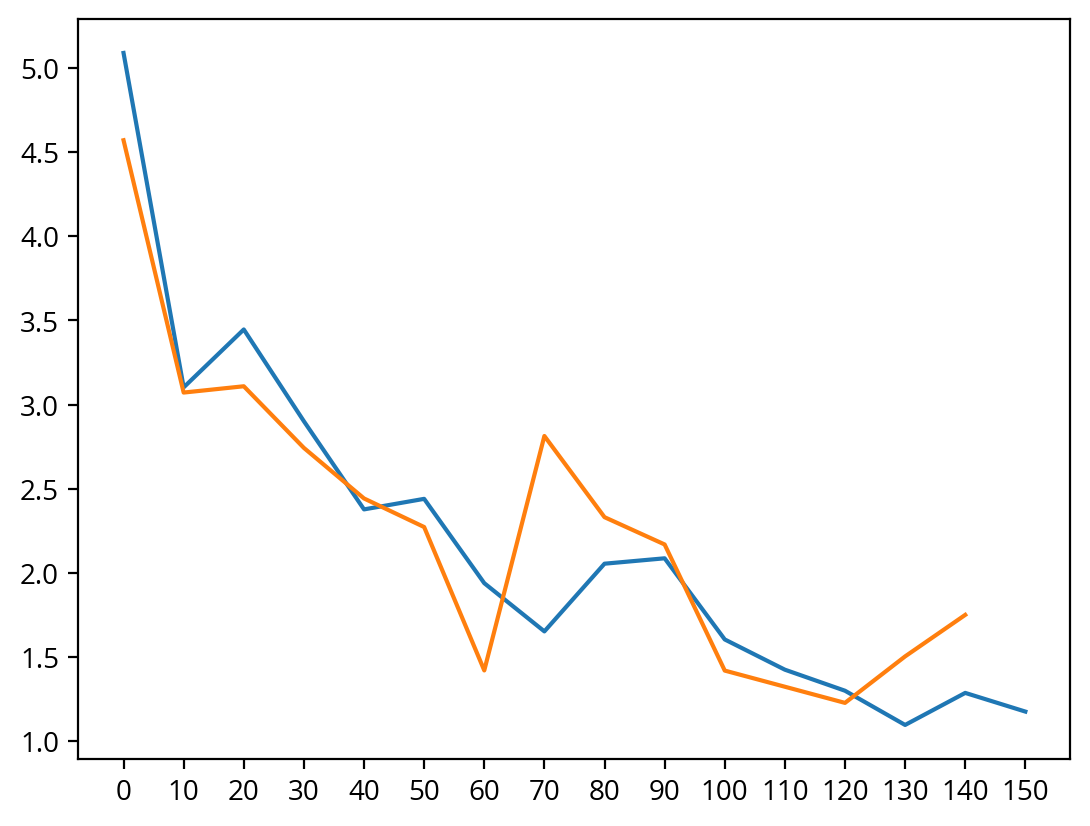

In [93]:
from src.gene_expression import load_transcription_for_name


expression_rep1 = load_transcription_for_name('nogene_chr16_775917_776355', 1)
expression_rep2 = load_transcription_for_name('nogene_chr16_775917_776355', 2)

plt.plot(expression_rep1)
plt.plot(expression_rep2)

In [106]:
from src.transcripts_dataset import load_transcripts_sets

combined_transcripts_set = load_transcripts_sets(output_dir, combined=True)
combined_transcripts_set

,chr,strand,start,stop,length
YAL068C,1,-,1807,2169,362
YAL067W-A,1,+,2480,2707,227
YAL067C,1,-,7235,9016,1781
YAL065C,1,-,11565,11951,386
YAL064W-B,1,+,12046,12426,380
...,...,...,...,...,...
nogene_chr16_883764_884048,16,-,883764,884048,285
nogene_chr16_900044_900421,16,-,900044,900421,378
nogene_chr16_930038_930990,16,-,930038,930990,953
nogene_chr16_937119_939102,16,+,937119,939102,1984


In [94]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner

tx_deconv_runner = CombinedDeconvolveGeneExpressionRunner(output_dir)

In [99]:
tx_deconv_runner.deconvolve_transcript_optimal_gamma('nogene_chr16_775917_776355',
    kappa=0.001, eta=0.264)


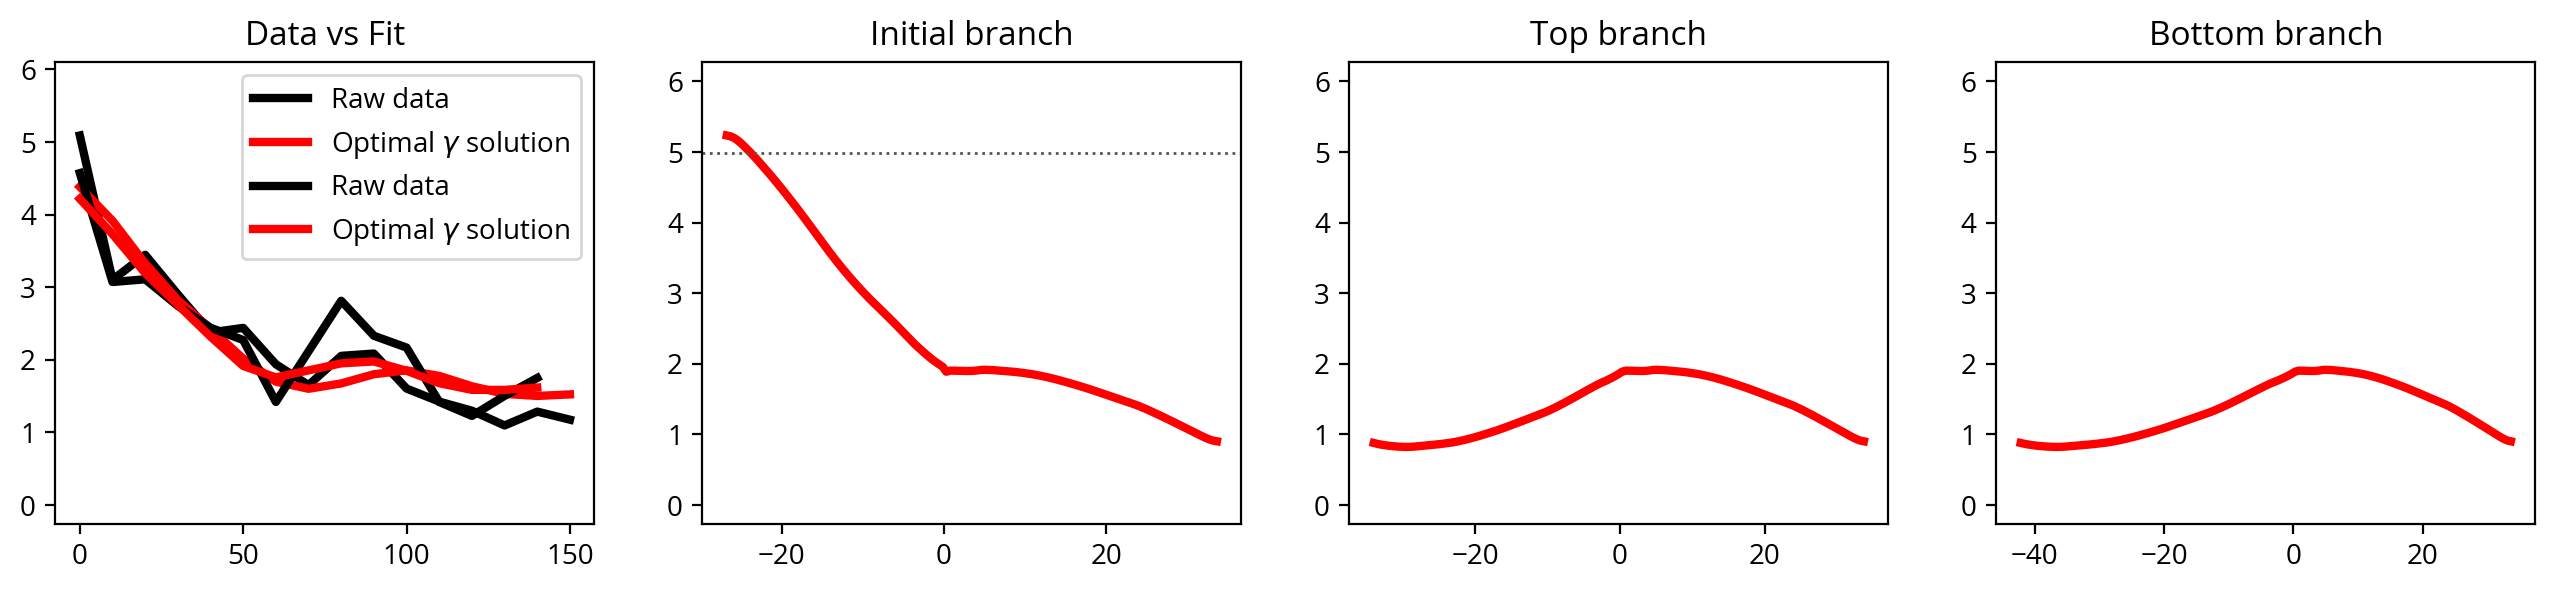

In [100]:
tx_deconv_runner.plot_solution()

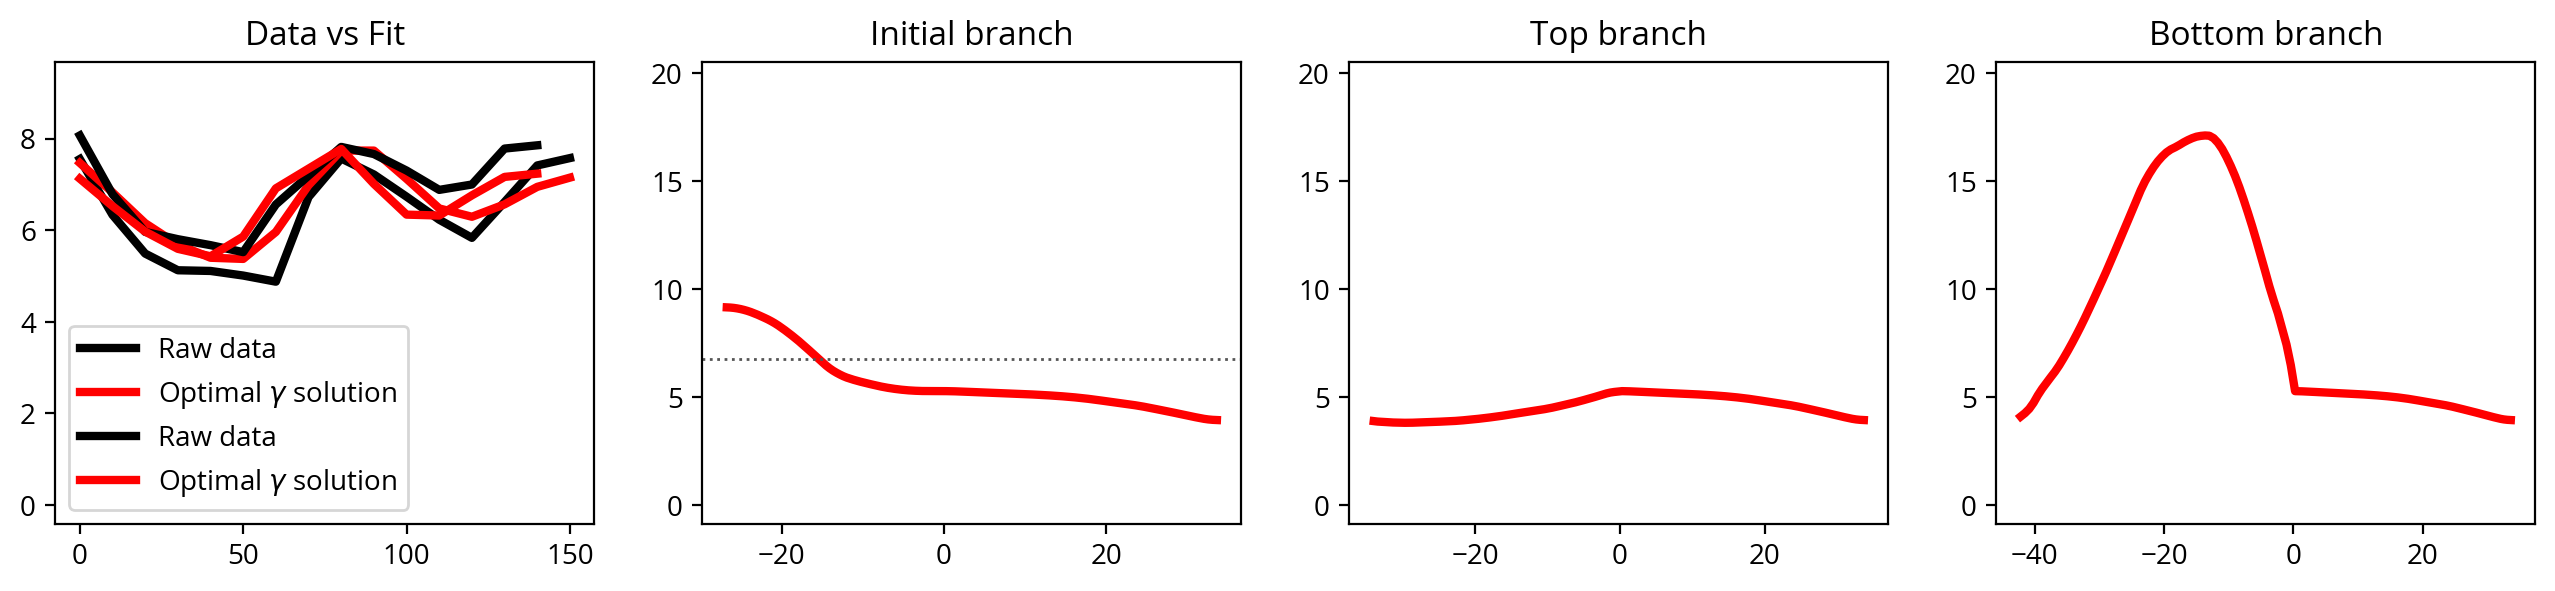

In [104]:
tx_deconv_runner.deconvolve_gene_optimal_gamma('DSE1',
    kappa=0.001, eta=0.264)
tx_deconv_runner.plot_solution()

<Axes: >

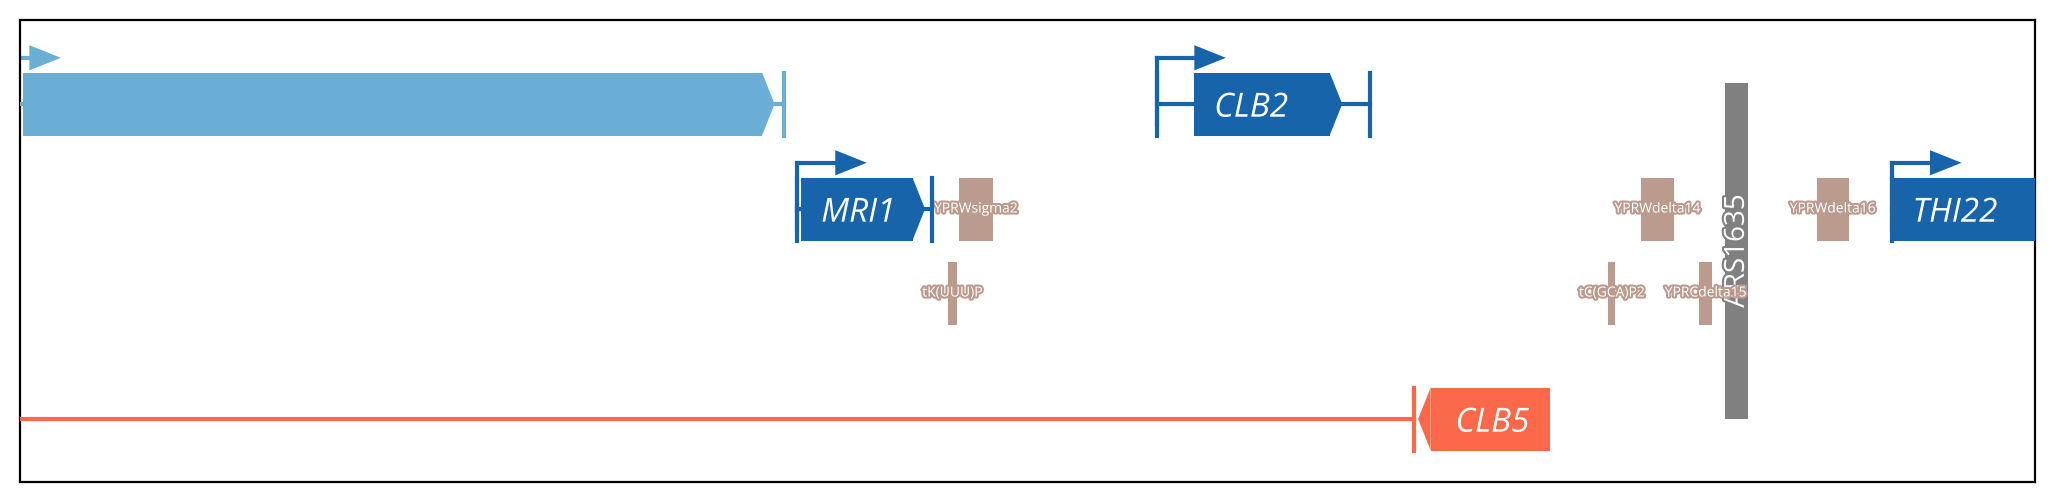

In [118]:
plt.figure(figsize=(13, 3))
orf_plotter.plot_orf_annotations(plt.gca())

In [137]:
from src.transcripts_dataset import load_transcripts_sets
txs = load_transcripts_sets('output/draft4_run/', combined=True)

In [163]:
# Load deconvolved gene expression
from src.deconv_data import load_gene_expression_fs, load_nongene_transcription_fs

outdir = 'output/draft4_run/'
gene_expression_dir = f"{outdir}genes_deconvolution/"
gene_expression_f = load_gene_expression_fs(gene_expression_dir)

In [169]:
from src.deconv_data import load_gene_expression_fs, load_nongene_transcription_fs

nongenic_f = load_nongene_transcription_fs(outdir)

0

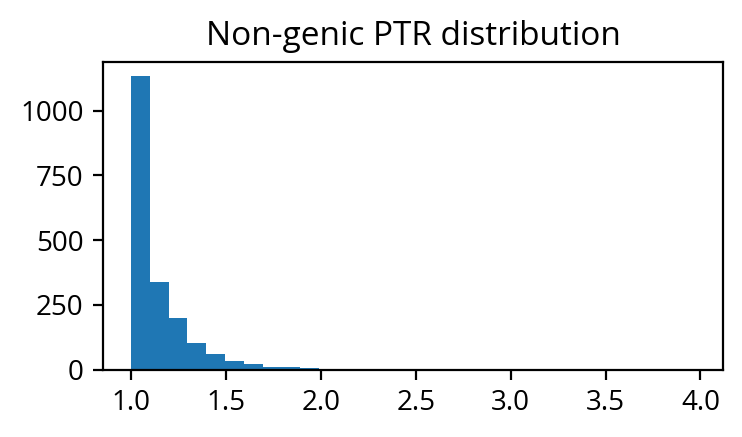

In [210]:
from src.peak_to_trough import compute_quantile_ptr_2d

nongenic_ptr = compute_quantile_ptr_2d(nongenic_f, eps=1)
nongenic_ptr_df = pd.DataFrame(nongenic_ptr, index=nongenic_f.index, columns=['ptr'])

plt.figure(figsize=(4, 2))
plt.hist(nongenic_ptr, bins=30)
plt.title("Non-genic PTR distribution")
0

In [260]:
from src.plot_helpers import plot_deconvolution_solution
from src.config import load_default_chrom_configs
from src.global_config import GlobalConstants

config1, config2 = load_default_chrom_configs()
    
def plot_nongenic(nongenic_f, name):
    tps1 = GlobalConstants.EXPRESSION_WT1_TIMEPOINTS
    tps2 = GlobalConstants.EXPRESSION_WT2_TIMEPOINTS
    F = nongenic_f.loc[name].values
    plot_deconvolution_solution(None, F, config1, tps1, tps2, plots=['i', 't', 'b'],
                               figsize=(7, 2), ylims=(-0.1, 12))
    plt.suptitle(f"{name}", fontweight='demi')
    plt.tight_layout()

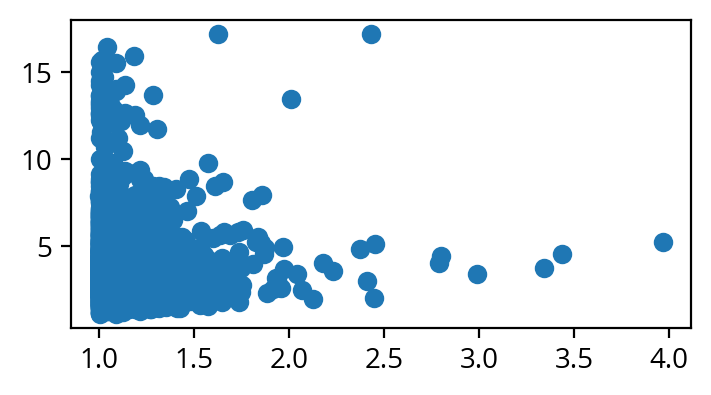

In [261]:
comparison_max_and_ptr = nongenic_ptr_df.copy()
comparison_max_and_ptr['max'] = nongenic_f[:-2].max(1)
plt.figure(figsize=(4, 2))
plt.scatter(comparison_max_and_ptr['ptr'], comparison_max_and_ptr['max'])

/var/folders/09/f2kb1zq9485dc8jvk0sbkbcr0000gn/T/ipykernel_39627/225632838.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


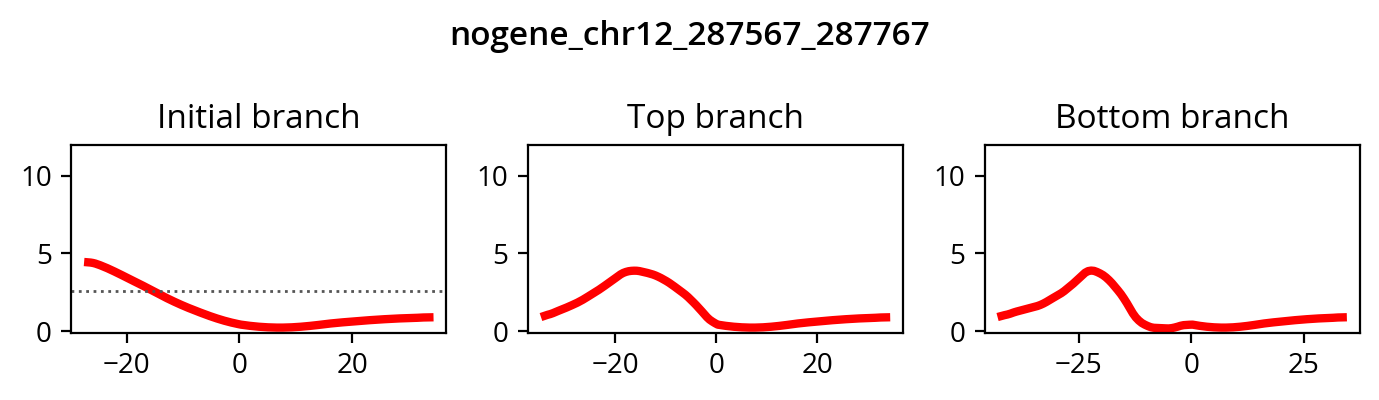

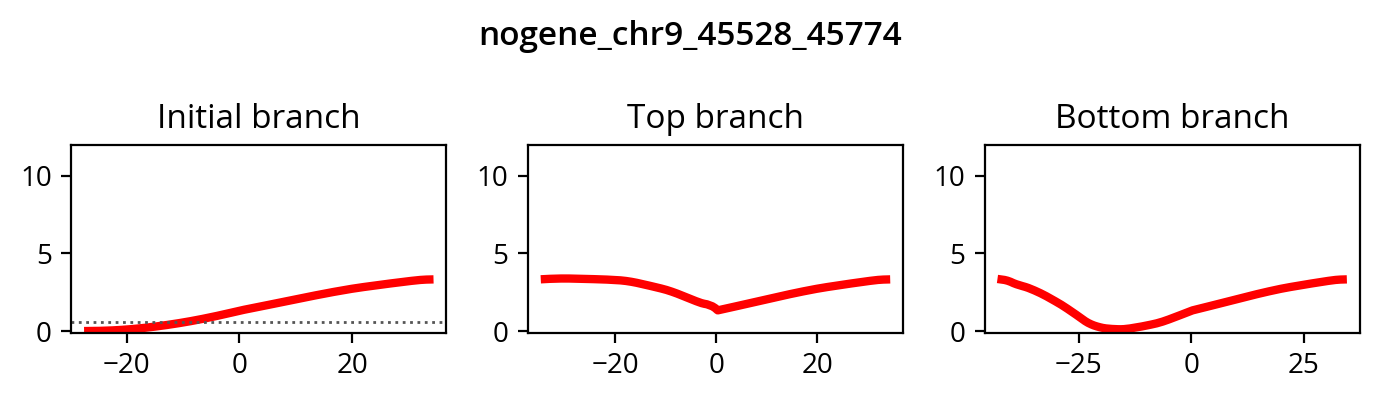

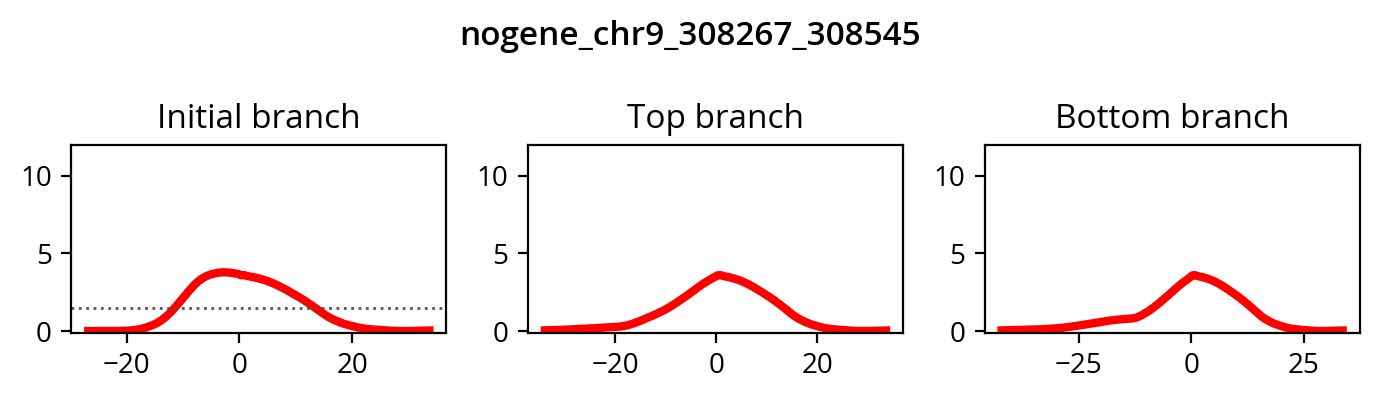

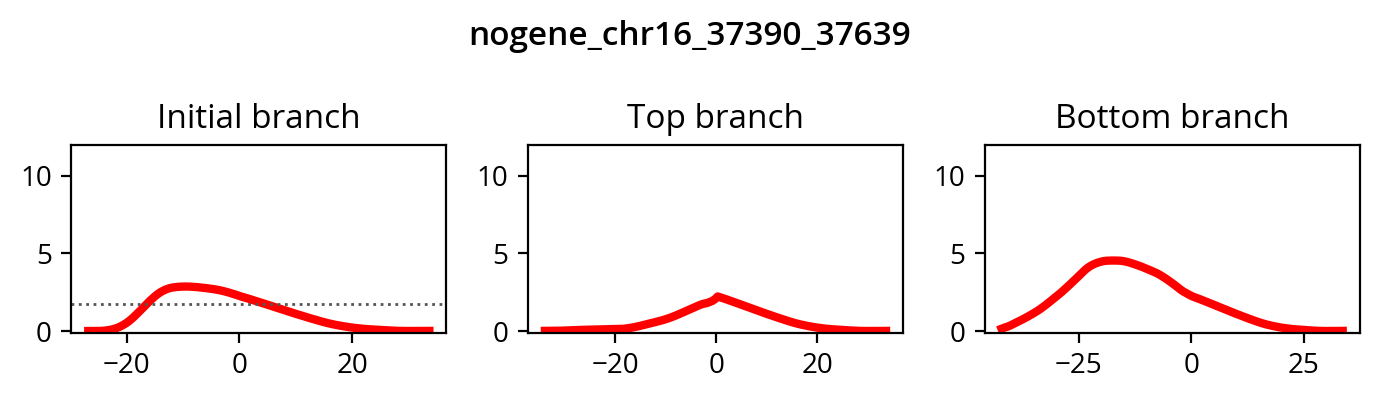

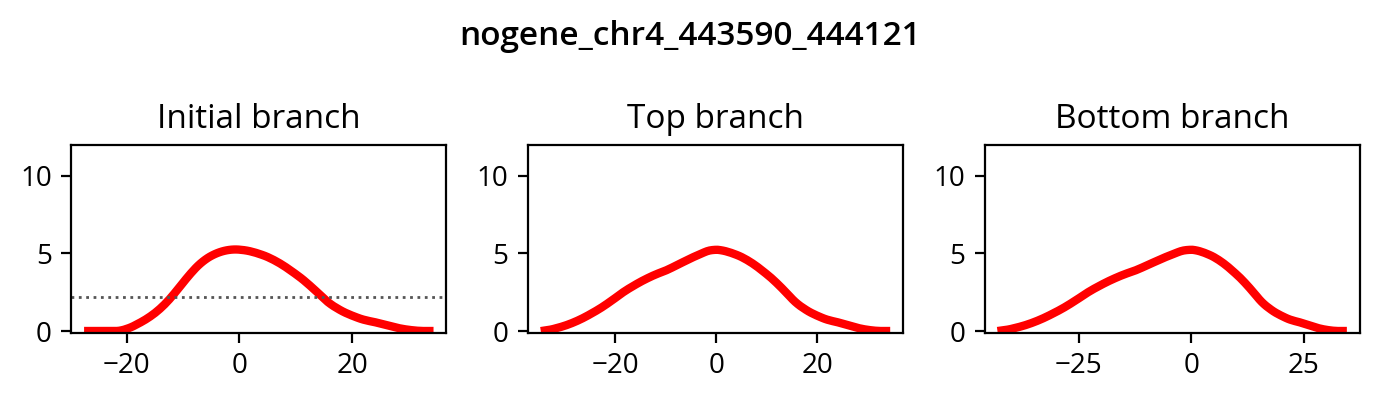

In [264]:

for tx_name, row in nongenic_ptr_df.sort_values('ptr').tail(5).iterrows():
    plot_nongenic(nongenic_f, tx_name)

In [270]:
from src.orf_plotter import load_default_orf_plotter

orf_plotter = load_default_orf_plotter()

In [280]:
genic, nongenic = load_transcripts_sets(output_dir)
tx_transcript = nongenic.loc['nogene_chr4_443590_444121']

In [291]:
from pipeline.antisense_transcripts_runner import TranscriptCallerRunner
from src.read_bam import read_rna_bam, get_rna_seq_filepaths_df

chrom = tx_transcript.chr

rna_filepaths_df = get_rna_seq_filepaths_df()

# This class currently has the RNA loading code
tx_calling_runner = TranscriptCallerRunner(outdir, chrom)

all_chrom_reads_rep1 = tx_calling_runner._load_all_chrom_reads(rna_filepaths_df, 1, chrom)
all_chrom_reads_rep2 = tx_calling_runner._load_all_chrom_reads(rna_filepaths_df, 2, chrom)


Creating directory: output/draft4_run//transcripts_calling...Directory exists. Skipping.
Replicate 1: 0/16 - 00:00:14.098
Freed 1893 objects after timepoint 0
Memory usage : 1503.6 MB (1.47 GB)
Replicate 1: 1/16 - 00:00:31.585
Freed 0 objects after timepoint 10
Memory usage : 1859.3 MB (1.82 GB)
Replicate 1: 2/16 - 00:00:49.198
Freed 0 objects after timepoint 20
Memory usage : 1811.9 MB (1.77 GB)
Replicate 1: 3/16 - 00:01:04.076
Freed 0 objects after timepoint 30
Memory usage : 1805.2 MB (1.76 GB)
Replicate 1: 4/16 - 00:01:19.796
Freed 0 objects after timepoint 40
Memory usage : 1809.3 MB (1.77 GB)
Replicate 1: 5/16 - 00:01:36.724
Freed 0 objects after timepoint 50
Memory usage : 1979.1 MB (1.93 GB)
Replicate 1: 6/16 - 00:01:53.402
Freed 0 objects after timepoint 60
Memory usage : 1669.0 MB (1.63 GB)
Replicate 1: 7/16 - 00:02:09.815
Freed 0 objects after timepoint 70
Memory usage : 1749.2 MB (1.71 GB)
Replicate 1: 8/16 - 00:02:27.746
Freed 0 objects after timepoint 80
Memory usage : 16

In [297]:
from src.transcript_boundary_caller import AntisenseTranscriptCaller

# We're going to setup a system to evaluate these nongenic transcripts systematically

# Let's load the raw RNA
all_chrom_reads_rep1

# We can save these to disk and/or the pileup

# Let's see how long pileup takes to generate
#tx_calling_runner._compute_pileups_advanced(all_chrom_reads_rep1, (10000, 20000), 1)

# Initialize caller
caller = AntisenseTranscriptCaller(
    chromosome=tx_calling_runner.chromosome,
    min_length=tx_calling_runner.min_length,
    max_gap=tx_calling_runner.max_gap,
    timer=tx_calling_runner.timer
)


In [301]:
caller.load_pileup_from_bam(all_chrom_reads_rep1, all_chrom_reads_rep2)

Starting pileup computation for chromosome 4 - 00:00:00.000
Completed pileup computation and replicate averaging - 00:01:38.986


In [ ]:
from src.rna_pileup_plotter import RNASeqPileupPlotter

rna_plotter = RNASeqPileupPlotter(outdir)
rna_plotter.set_chrom_span(tx_transcript.chr, span, 1)
orf_plotter.set_span_chrom(span, tx_transcript.chr)

[]

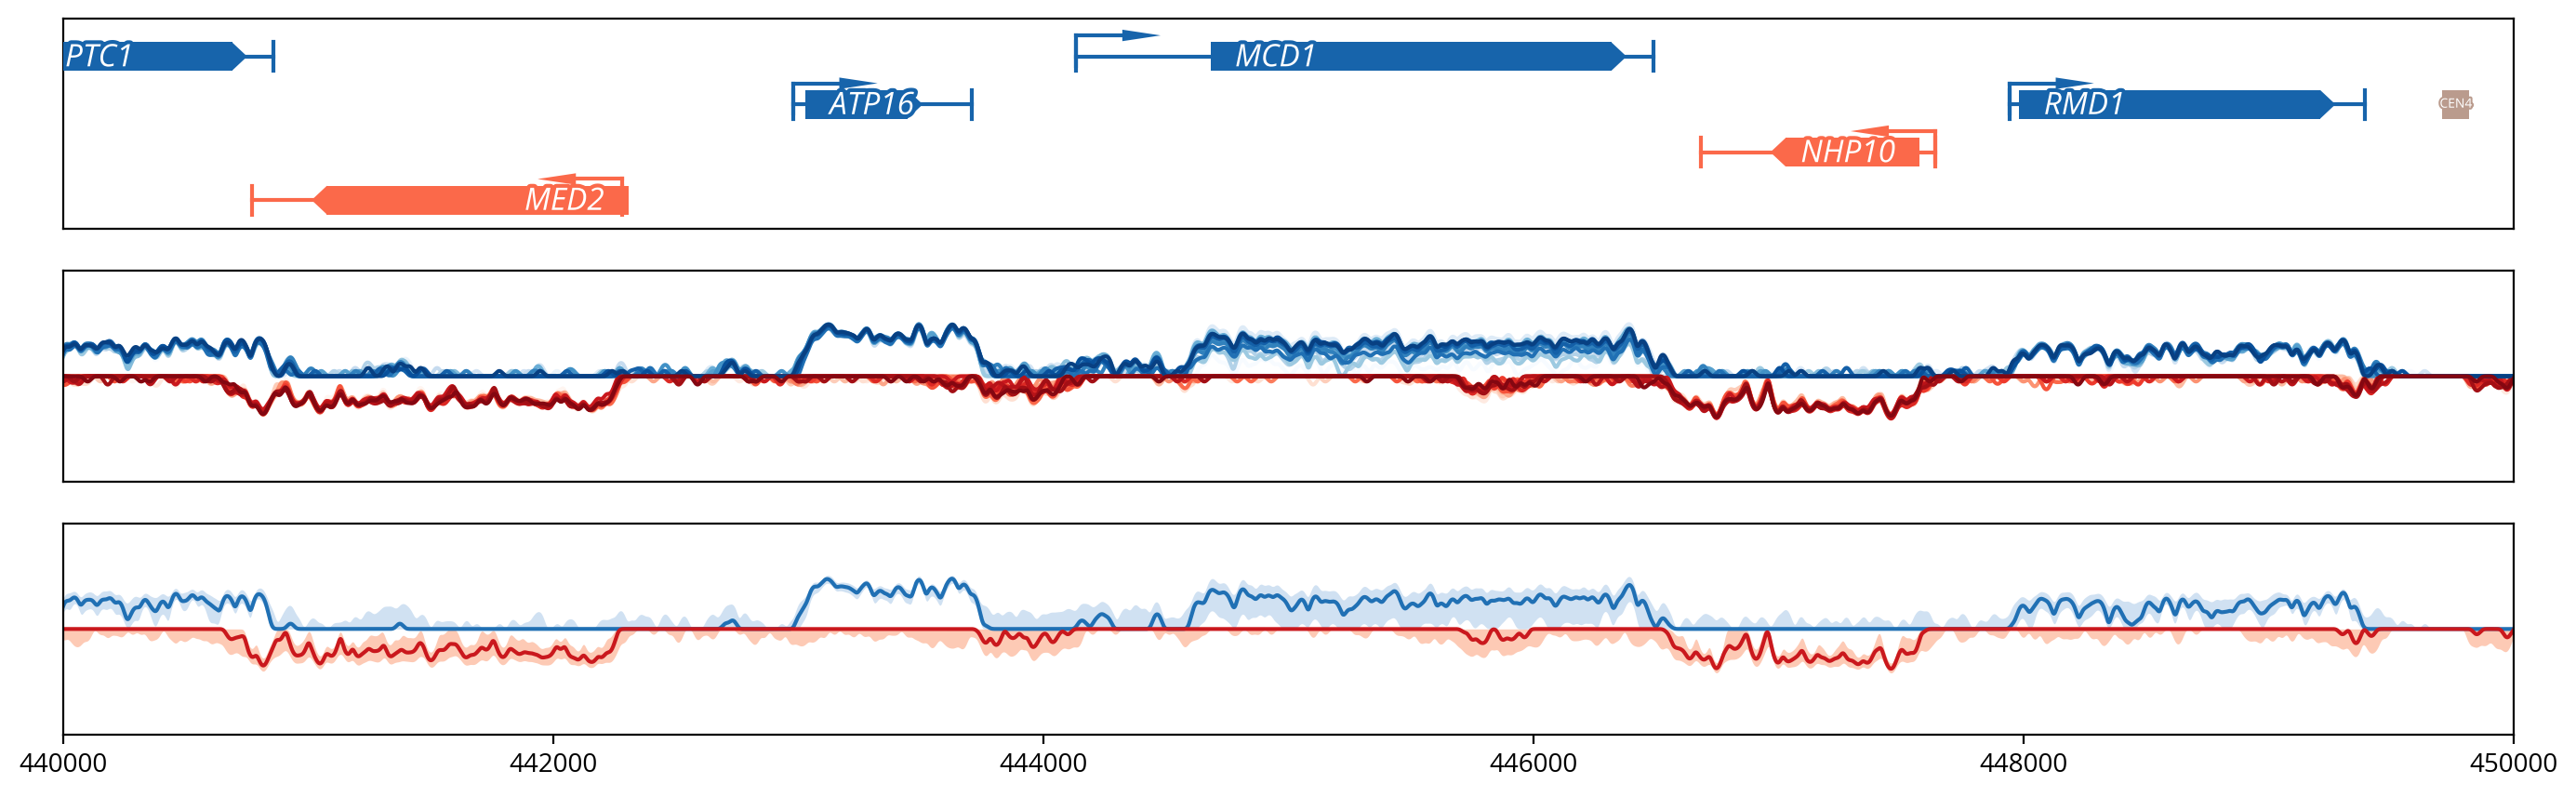

In [395]:
span = 440000, 450000
watson_selected_pileup = caller.watson_rep1[range(span[0], span[1])]
crick_selected_pileup = caller.crick_rep1[range(span[0], span[1])]

plt.figure(figsize=(17, 5))

plt.subplot(3, 1, 1)
ax = plt.gca()
orf_plotter.plot_orf_annotations(ax)

plt.subplot(3, 1, 2)
ax = plt.gca()
rna_plotter.plot_pileup(ax=ax, mode='timepoints')
ax.set_xticks([])
ax.set_yticks([])

plt.subplot(3, 1, 3)
ax = plt.gca()
rna_plotter.plot_pileup(ax=ax, mode='minmax')
ax.set_yticks([])